In [1]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("/content/vmCloud_data.csv")

In [3]:
df["task_type"].fillna(df["task_type"].mode()[0], inplace=True)
df["task_priority"].fillna(df["task_priority"].mode()[0], inplace=True)
df["task_status"].fillna(df["task_status"].mode()[0], inplace=True)

<ipython-input-3-05323e600508>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["task_type"].fillna(df["task_type"].mode()[0], inplace=True)
<ipython-input-3-05323e600508>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [4]:
df.drop(columns=["vm_id"], inplace=True)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek  # Monday=0, Sunday=6
df.drop(columns=["timestamp"], inplace=True)

In [5]:
# FEATURE ENGINEERING
df["cpu_memory_ratio"] = df["cpu_usage"] / (df["memory_usage"] + 1e-5)
df["power_per_instruction"] = df["power_consumption"] / (df["num_executed_instructions"] + 1e-5)
df["efficiency_score"] = df["energy_efficiency"] / (df["execution_time"] + 1e-5)
df["network_per_execution"] = df["network_traffic"] / (df["execution_time"] + 1e-5)

In [6]:
df.head(5)

,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,hour,day_of_week,cpu_memory_ratio,power_per_instruction,efficiency_score,network_per_execution
0,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting,9.0,2.0,0.695133,0.038237,0.007983,2.376157
1,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed,4.0,3.0,2.391786,0.067740,0.008451,NaN
2,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed,23.0,4.0,NaN,0.042216,0.032366,8.278604
3,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed,11.0,3.0,0.618476,0.033295,0.032176,NaN
4,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,io,medium,waiting,8.0,2.0,NaN,0.106948,0.006363,NaN


In [7]:
from sklearn.preprocessing import LabelEncoder

for col in ["task_type", "task_priority", "task_status"]:
    df[col] = LabelEncoder().fit_transform(df[col])

In [8]:
print("Unique values in task_type:", df["task_type"].unique())
print("Unique values in task_priority:", df["task_priority"].unique())
print("Unique values in task_status:", df["task_status"].unique())


Unique values in task_type: [2 1 0]
Unique values in task_priority: [2 0 1]
Unique values in task_status: [2 0 1]


In [9]:
df.head(5)

,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,hour,day_of_week,cpu_memory_ratio,power_per_instruction,efficiency_score,network_per_execution
0,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,2,2,2,9.0,2.0,0.695133,0.038237,0.007983,2.376157
1,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,1,0,0,4.0,3.0,2.391786,0.067740,0.008451,NaN
2,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,1,2,0,23.0,4.0,NaN,0.042216,0.032366,8.278604
3,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,0,0,0,11.0,3.0,0.618476,0.033295,0.032176,NaN
4,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,1,2,2,8.0,2.0,NaN,0.106948,0.006363,NaN


In [10]:
print(df.isnull().sum())  # Check missing values for all columns

cpu_usage                    199038
memory_usage                 200510
network_traffic              199481
power_consumption            200271
num_executed_instructions    199686
execution_time               199827
energy_efficiency            200042
task_type                         0
task_priority                     0
task_status                       0
hour                         200666
day_of_week                  200666
cpu_memory_ratio             379945
power_per_instruction        380059
efficiency_score             379799
network_per_execution        379254
dtype: int64


In [11]:
df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)
print(df.isnull().sum())

cpu_usage                    0
memory_usage                 0
network_traffic              0
power_consumption            0
num_executed_instructions    0
execution_time               0
energy_efficiency            0
task_type                    0
task_priority                0
task_status                  0
hour                         0
day_of_week                  0
cpu_memory_ratio             0
power_per_instruction        0
efficiency_score             0
network_per_execution        0
dtype: int64


In [12]:
# Features (X) and Target Variables (Y)
X = df.drop(columns=["cpu_usage", "memory_usage", "network_traffic", "power_consumption"])  # Input features
Y = df[["cpu_usage", "memory_usage", "network_traffic", "power_consumption"]]  # Target variables

In [13]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [14]:
X_test.iloc[6]


,1764397
num_executed_instructions,5758.000000
execution_time,2.817718
energy_efficiency,0.143730
task_type,0.000000
task_priority,1.000000
task_status,2.000000
hour,11.487846
day_of_week,2.982607
cpu_memory_ratio,6.035522
power_per_instruction,0.068331


In [15]:
y_test.iloc[6]

,1764397
cpu_usage,67.920077
memory_usage,11.253379
network_traffic,869.667428
power_consumption,393.448132


In [16]:
# Define the base LightGBM model
lgb_model = lgb.LGBMRegressor(
    boosting_type='gbdt',
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Use MultiOutputRegressor to handle multiple targets
model = MultiOutputRegressor(lgb_model)

# Train the model
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate model performance using Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
print("Mean Absolute Error for each target variable:", mae)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.233861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1827
[LightGBM] [Info] Number of data points in the train set: 1600000, number of used features: 12
[LightGBM] [Info] Start training from score 50.004357
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.228804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1827
[LightGBM] [Info] Number of data points in the train set: 1600000, number of used features: 12
[LightGBM] [Info] Start training from score 49.982809
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.222600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1827
[LightGBM] [Info] Number of data points in the train set: 1600000, number of used features: 12
[LightGBM] [Info] S

In [17]:
import joblib
joblib.dump(model, "lightGBM_model.pkl")

['lightGBM_model.pkl']

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import joblib

# Load the trained LightGBM model
lgb_multi_model = joblib.load("lightGBM_model.pkl")

# Predict using LightGBM
y_pred_lgb = lgb_multi_model.predict(X_test)

# Calculate MAE for LightGBM
mae_lgb = mean_absolute_error(y_test, y_pred_lgb, multioutput='raw_values')
print("LightGBM MAE:", mae_lgb)

# Define and train Random Forest model
rf_model = RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42)
rf_multi_model = MultiOutputRegressor(rf_model)
rf_multi_model.fit(X_train, y_train)

# Predict using Random Forest
y_pred_rf = rf_multi_model.predict(X_test)

# Calculate MAE for Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf, multioutput='raw_values')
print("Random Forest MAE:", mae_rf)

# Compare Results
for i, col in enumerate(["cpu_usage", "memory_usage", "network_traffic", "power_consumption"]):
    print(f"{col}: LightGBM MAE = {mae_lgb[i]:.4f}, Random Forest MAE = {mae_rf[i]:.4f}")


LightGBM MAE: [14.32377737 14.30358613 29.24897506 14.09661391]
Random Forest MAE: [ 14.30239204  14.34661923 102.50060403  50.07532833]
cpu_usage: LightGBM MAE = 14.3238, Random Forest MAE = 14.3024
memory_usage: LightGBM MAE = 14.3036, Random Forest MAE = 14.3466
network_traffic: LightGBM MAE = 29.2490, Random Forest MAE = 102.5006
power_consumption: LightGBM MAE = 14.0966, Random Forest MAE = 50.0753


In [19]:
from sklearn.metrics import r2_score

# Calculate R² Score for LightGBM
r2_lgb = r2_score(y_test, y_pred_lgb)

# Calculate R² Score for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)

# Print only R² Score results (since MAE is already printed)
print("\n🔹 LightGBM Performance:")
print(f"R² Score: {r2_lgb:.4f}")

print("\n🔹 Random Forest Performance:")
print(f"R² Score: {r2_rf:.4f}")

# Compare Models
if r2_lgb > r2_rf:
    print("\n LightGBM has a HIGHER R² Score, meaning it fits the data better.")
else:
    print("\n Random Forest has a HIGHER R² Score, meaning it fits the data better.")



🔹 LightGBM Performance:
R² Score: 0.6970

🔹 Random Forest Performance:
R² Score: 0.5917

 LightGBM has a HIGHER R² Score, meaning it fits the data better.


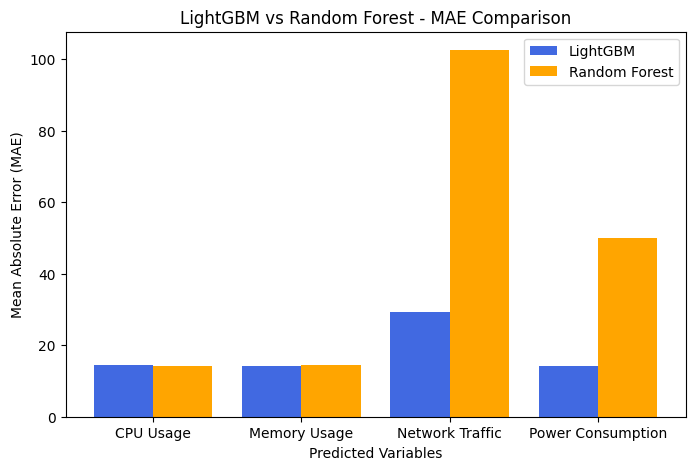

In [21]:
#BAR CHART FOR MAE
import numpy as np
import matplotlib.pyplot as plt

metrics = ["CPU Usage", "Memory Usage", "Network Traffic", "Power Consumption"]
x = np.arange(len(metrics))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, mae_lgb, 0.4, label="LightGBM", color='royalblue')
plt.bar(x + 0.2, mae_rf, 0.4, label="Random Forest", color='orange')

plt.xlabel("Predicted Variables")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("LightGBM vs Random Forest - MAE Comparison")
plt.xticks(x, metrics)
plt.legend()
plt.show()

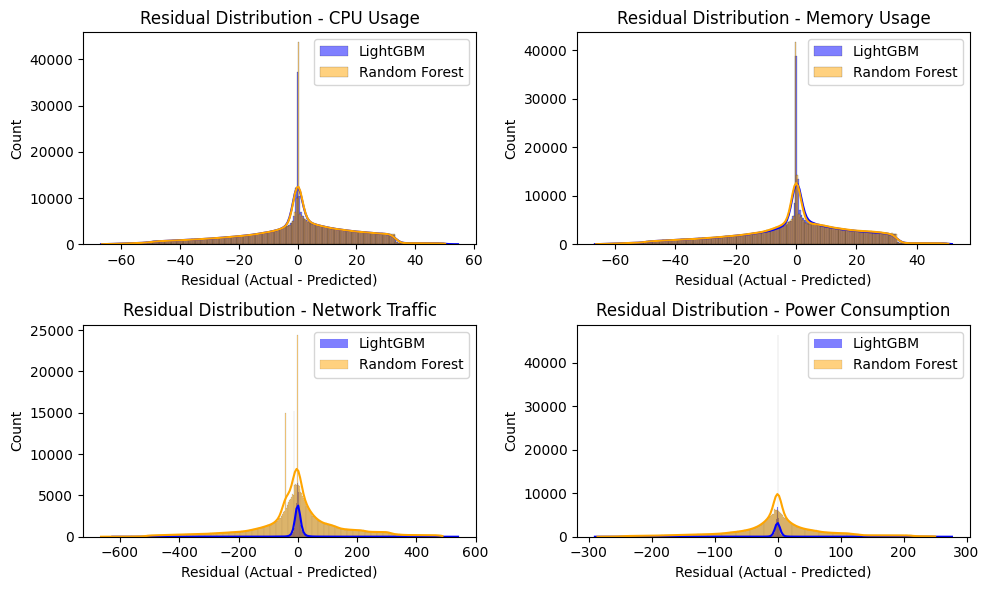

In [ ]:
#COMPUTE RESIDUALS(ERROR DISTRIBUTION)
import seaborn as sns

residuals_lgb = y_test - y_pred_lgb
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
for i, col in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    sns.histplot(residuals_lgb.iloc[:, i], color='blue', label='LightGBM', kde=True, alpha=0.5)
    sns.histplot(residuals_rf.iloc[:, i], color='orange', label='Random Forest', kde=True, alpha=0.5)
    plt.title(f"Residual Distribution - {col}")
    plt.xlabel("Residual (Actual - Predicted)")
    plt.legend()

plt.tight_layout()
plt.show()


In [25]:
import joblib
import pandas as pd

loaded_model = joblib.load("lightGBM_model.pkl")

def get_user_input():
    """
    This function asks the user to input values for all the features.
    """
    user_input = {}
    user_input['num_executed_instructions'] = float(input("Enter num_executed_instructions: "))
    user_input['execution_time'] = float(input("Enter execution_time: "))
    user_input['energy_efficiency'] = float(input("Enter energy_efficiency: "))
    user_input['task_type'] = int(input("Enter task_type (compute=0, i/o=1, network=2): "))
    user_input['task_priority'] = int(input("Enter task_priority (high=0, low=1, medium=2): "))
    user_input['task_status'] = int(input("Enter task_status (completed=0, running=1, waiting=2): "))
    user_input['hour'] = int(input("Enter hour (0-23): "))
    user_input['day_of_week'] = int(input("Enter day_of_week (0=Monday, 6=Sunday): "))
    user_input['cpu_memory_ratio'] = float(input("Enter cpu_memory_ratio: "))
    user_input['power_per_instruction'] = float(input("Enter power_per_instruction: "))
    user_input['efficiency_score'] = float(input("Enter efficiency_score: "))
    user_input['network_per_execution'] = float(input("Enter network_per_execution: "))


    return pd.DataFrame([user_input])

def predict_labels_from_input(user_input_df, selected_labels):
    """
    This function predicts the selected labels based on user input.
    """
    all_predictions = loaded_model.predict(user_input_df)  # Predict all labels

    # Map selected labels to their respective indices
    labels = ['cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption']
    label_indices = [labels.index(label) for label in selected_labels]  # Get indices for selected labels

    # Return only the predictions for the selected labels
    selected_predictions = [all_predictions[0][index] for index in label_indices]

    return selected_predictions

# Get user input
user_input_df = get_user_input()

# Let user select which values to predict
available_labels = ['cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption']
print("\nAvailable labels for prediction:", available_labels)
selected_labels = input("Enter the labels to predict (comma-separated, e.g., cpu_usage,memory_usage): ").split(',')

# Remove extra spaces from user input
selected_labels = [label.strip() for label in selected_labels]

# Predict and display results
predictions = predict_labels_from_input(user_input_df, selected_labels)

print("\nPredicted Values:")
for label, value in zip(selected_labels, predictions):
    print(f"{label}: {value:.2f}")

Enter num_executed_instructions: 5758
Enter execution_time: 2.8
Enter energy_efficiency: 0.14
Enter task_type (compute=0, i/o=1, network=2): 0
Enter task_priority (high=0, low=1, medium=2): 1
Enter task_status (completed=0, running=1, waiting=2): 2
Enter hour (0-23): 11
Enter day_of_week (0=Monday, 6=Sunday): 2
Enter cpu_memory_ratio: 6.03
Enter power_per_instruction: 0.068
Enter efficiency_score: 0.051
Enter network_per_execution: 308.64

Available labels for prediction: ['cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption']
Enter the labels to predict (comma-separated, e.g., cpu_usage,memory_usage): cpu_usage, memory_usage, network_traffic, power_consumption

Predicted Values:
cpu_usage: 65.63
memory_usage: 11.14
network_traffic: 932.77
power_consumption: 392.52
